In [1]:
# Cell 1 — Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid', palette='muted')

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [4]:
# Cell 2 — Upload & Load Dataset
from google.colab import files
import io

print("📂 Please select your CSV file...")
uploaded = files.upload()

# Auto-detect the filename — no hardcoding
filename = list(uploaded.keys())[0]
print(f"\n✅ File received: '{filename}'")

df = pd.read_csv(io.BytesIO(uploaded[filename]), encoding='latin-1')

print(f"\n✅ Dataset loaded successfully!")
print(f"   Rows    : {df.shape[0]}")
print(f"   Columns : {df.shape[1]}")
print(f"\nColumn names:")
print(df.columns.tolist())

📂 Please select your CSV file...


Saving Sample - Superstore 2.csv to Sample - Superstore 2 (1).csv

✅ File received: 'Sample - Superstore 2 (1).csv'

✅ Dataset loaded successfully!
   Rows    : 9994
   Columns : 21

Column names:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


In [5]:
print("Dataset Shape:", df.shape)

Dataset Shape: (9994, 21)


In [6]:
print(df.dtypes)

Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object


In [7]:
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found")

No missing values found


In [8]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [9]:
# Convert date columns from object to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date']  = pd.to_datetime(df['Ship Date'])

In [10]:
# Remove duplicate rows if any
before = len(df)
df.drop_duplicates(inplace=True)
print(f"Duplicates removed: {before - len(df)}")


Duplicates removed: 0


In [11]:
# Strip whitespace from all text columns
str_cols = df.select_dtypes(include='object').columns
df[str_cols] = df[str_cols].apply(lambda x: x.str.strip())

In [12]:
#Feature Engineering
# Extract time-based features from Order Date
df['Year']          = df['Order Date'].dt.year
df['Month']         = df['Order Date'].dt.month
df['Quarter']       = df['Order Date'].dt.quarter
df['Week']          = df['Order Date'].dt.isocalendar().week.astype(int)
df['Day_of_Week']   = df['Order Date'].dt.dayofweek
df['Month_Name']    = df['Order Date'].dt.strftime('%b')

In [13]:
# Shipping duration — how many days to ship
df['Shipping_Days'] = (df['Ship Date'] - df['Order Date']).dt.days

# Verify
print("New features added:")
print(df[['Order Date', 'Year', 'Month', 'Quarter', 'Week', 'Day_of_Week', 'Shipping_Days']].head())
print(f"\nFinal shape: {df.shape}")

New features added:
  Order Date  Year  Month  Quarter  Week  Day_of_Week  Shipping_Days
0 2016-11-08  2016     11        4    45            1              3
1 2016-11-08  2016     11        4    45            1              3
2 2016-06-12  2016      6        2    23            6              4
3 2015-10-11  2015     10        4    41            6              7
4 2015-10-11  2015     10        4    41            6              7

Final shape: (9994, 28)


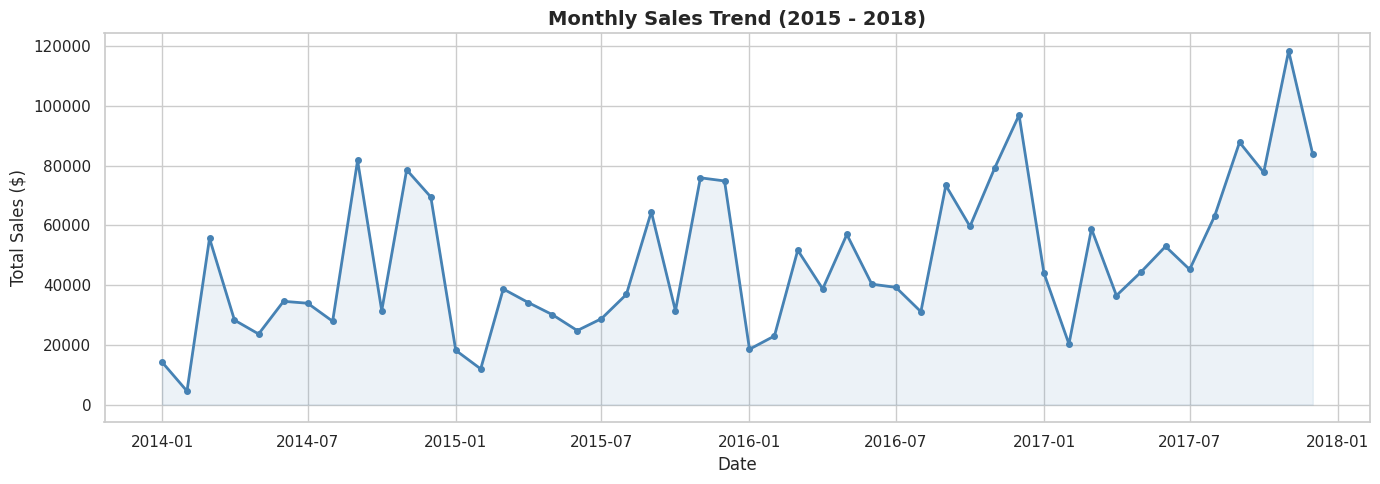

Chart saved: monthly_sales_trend.png


In [14]:
# Cell 6 — Monthly Sales Trend

monthly = df.groupby(['Year', 'Month'])['Sales'].sum().reset_index()
monthly['Date'] = pd.to_datetime(monthly[['Year', 'Month']].assign(Day=1))
monthly.sort_values('Date', inplace=True)

plt.figure(figsize=(14, 5))
plt.plot(monthly['Date'], monthly['Sales'], color='steelblue', linewidth=2, marker='o', markersize=4)
plt.fill_between(monthly['Date'], monthly['Sales'], alpha=0.1, color='steelblue')
plt.title('Monthly Sales Trend (2015 - 2018)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Total Sales ($)')
plt.tight_layout()
plt.savefig('monthly_sales_trend.png', dpi=150)
plt.show()
print("Chart saved: monthly_sales_trend.png")

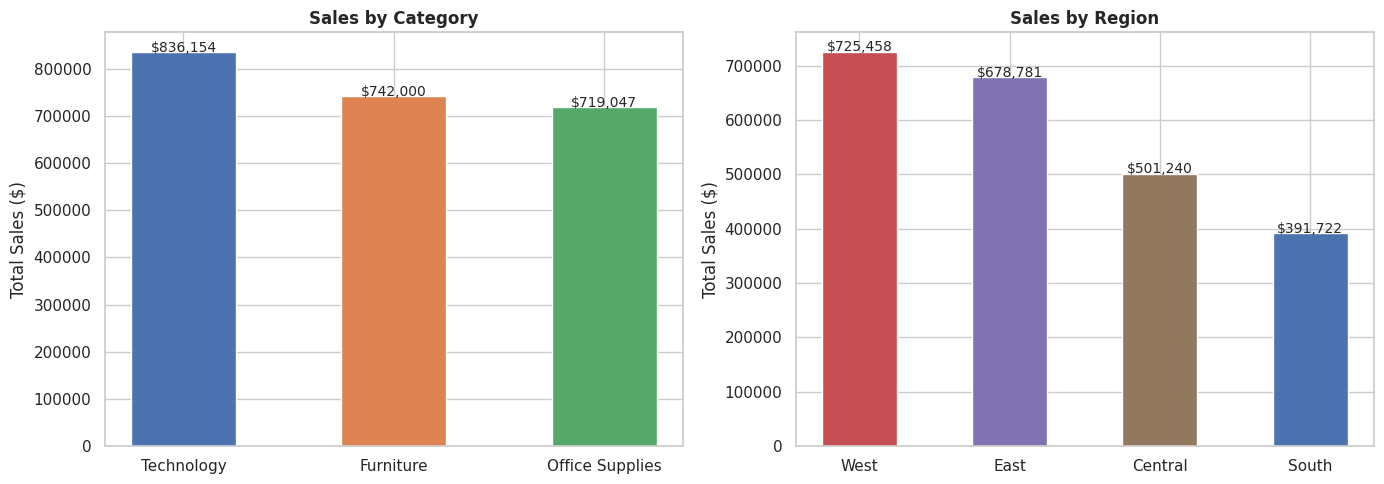

Chart saved: sales_by_category_region.png


In [15]:
# Cell 7 — Sales by Category and Region

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Category breakdown
cat_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
axes[0].bar(cat_sales.index, cat_sales.values, color=['#4C72B0', '#DD8452', '#55A868'], width=0.5)
axes[0].set_title('Sales by Category', fontweight='bold')
axes[0].set_ylabel('Total Sales ($)')
for i, v in enumerate(cat_sales.values):
    axes[0].text(i, v + 1000, f'${v:,.0f}', ha='center', fontsize=10)

# Region breakdown
reg_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
axes[1].bar(reg_sales.index, reg_sales.values, color=['#C44E52', '#8172B2', '#937860', '#4C72B0'], width=0.5)
axes[1].set_title('Sales by Region', fontweight='bold')
axes[1].set_ylabel('Total Sales ($)')
for i, v in enumerate(reg_sales.values):
    axes[1].text(i, v + 1000, f'${v:,.0f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('sales_by_category_region.png', dpi=150)
plt.show()
print("Chart saved: sales_by_category_region.png")

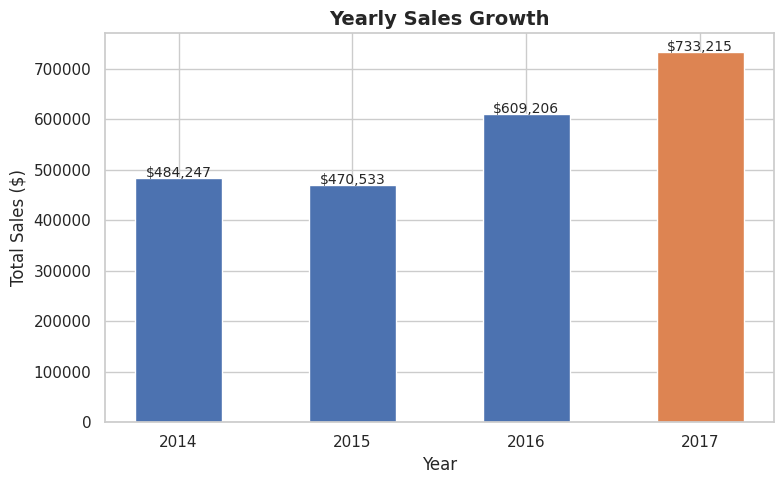

Chart saved: yearly_sales_growth.png


In [16]:
# Cell 8 — Yearly Sales Growth

yearly = df.groupby('Year')['Sales'].sum().reset_index()

plt.figure(figsize=(8, 5))
bars = plt.bar(yearly['Year'].astype(str), yearly['Sales'],
               color=['#4C72B0', '#4C72B0', '#4C72B0', '#DD8452'], width=0.5)
plt.title('Yearly Sales Growth', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Total Sales ($)')
for bar, val in zip(bars, yearly['Sales']):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2000,
             f'${val:,.0f}', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('yearly_sales_growth.png', dpi=150)
plt.show()
print("Chart saved: yearly_sales_growth.png")

In [19]:
# Cell 9 — Save cleaned dataset and download all outputs

# Save cleaned dataframe
df.to_csv('superstore_cleaned.csv', index=False)
print(f"Cleaned dataset saved")
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

# Download all files to your local machine
from google.colab import files


files.download('monthly_sales_trend.png')



print("All files downloaded. Move them to your task1 folder now.")

Cleaned dataset saved
Rows    : 9994
Columns : 28


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All files downloaded. Move them to your task1 folder now.
